In [257]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../analysisFunctions'))
sys.path.insert(0, dir1)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
import doubleml as dml
import pymc as pm
import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
import causalpy as cp
import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score

In [2]:
myPredictorsDf = pd.read_csv('../predictorsDf.csv')

In [167]:
myXValue = myPredictorsDf.drop(columns= ['CPC_SC3', 'CPC12', 'J0_SEX', 'SUBJID', 'BARTHEL_SC', 'SOFA_SC7', 'DS_DC', 'DAYS_ALIVE_30', 'J0_GLASGOW_CONTROLE', 'J0_CORDA_DOS'])
myFilter = myPredictorsDf['groupe'] != 2
myXValue = myXValue[myFilter]
myYValue = myPredictorsDf['CPC12']
X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[myFilter][['CPC12', 'groupe']], test_size=0.30)

In [4]:
myGridSearchCv = gridSearchKFoldRegression(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='r2')
myBestModel = myGridSearchCv.best_estimator_

Best parameters: {'clf': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...), 'clf__max_depth': 2, 'clf__n_estimators': 5}
Best cross val r2 score: 0.0385
R2 score  on test set: -0.029885919003301842


In [263]:
myGridSearchCv = gridSearchKFoldClassification(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='roc_auc')
myBestModel = myGridSearchCv.best_estimator_

Best parameters: {'clf': LogisticRegression(), 'clf__C': 0.1}
Best cross val roc_auc score: 0.8310
Area under the receiver operating curve on test set is 0.8048
Accuracy score on test set is 0.9257


In [98]:
# myFeatureImportancesDf = getTopFeatures(myGridSearchCv, list(myBestModel.named_steps['preprocessor'].get_feature_names_out()), X_train, y_train)

Optimization terminated successfully.
         Current function value: 0.264361
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.263447
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 1.0626593687124455
p-value: 0.587822830972219
Degress of freedom: 2.0


0.587822830972219

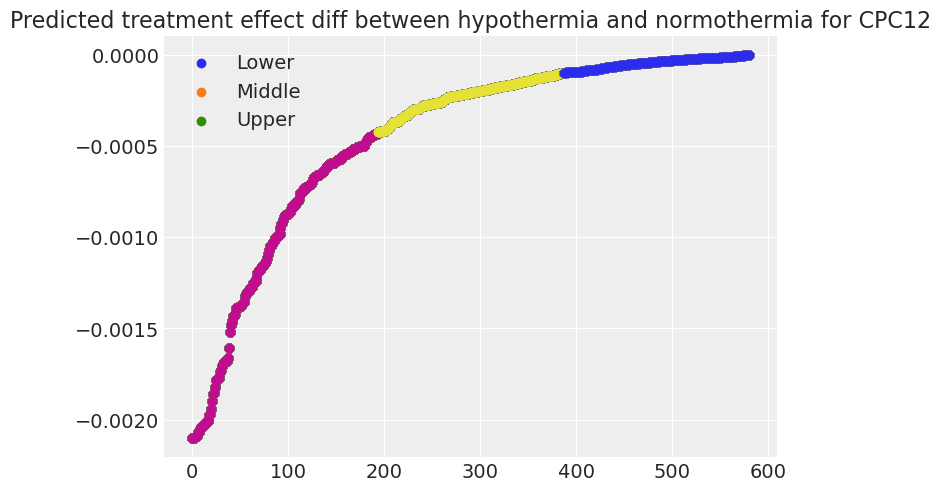

In [264]:
getTreatmentEffectDiff(myXValue, myYValue, myBestModel, 'CPC12')

In [101]:
myNewXValue = myXValue.copy()
myNewXValue = myNewXValue.drop(columns=['groupe'])
myPipelineSteps = getDefaultPipelineSteps(myNewXValue)
myPipelineSteps.append(('clf', StepMix(n_components=3, n_init=100, measurement="categorical")))
myPipeline = Pipeline(myPipelineSteps)
myPipeline.fit(myNewXValue)
myGroups = myPipeline.predict(myNewXValue)
myClassifierTest = 'CPC12'
p_value, myModel, myData= getTreatmentEffectDiffUnsupervised(myXValue, myPredictorsDf[myClassifierTest], myGroups, myClassifierTest)
plotPredictedEffectDiff(aData = myData, aBestModel = myModel)
print(silhouette_score(Pipeline(getDefaultPipelineSteps(myNewXValue)).fit_transform(myNewXValue), myGroups))

Fitting StepMix...


Initializations (n_init) :   7%|█▍                  | 7/100 [01:08<15:06,  9.74s/it, max_LL=-2.51e+4, max_avg_LL=-43.3]


KeyboardInterrupt: 

C:\Program Files\miniconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Optimization terminated successfully.
         Current function value: 0.257125
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.256295
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.9644390418613966
p-value: 0.32607099270270573
Degress of freedom: 1.0
Silhouette Score of Clusters: 0.045709901269425576


C:\Users\mbranda1\lcicm\analysisFunctions\machine_learning.py:277: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


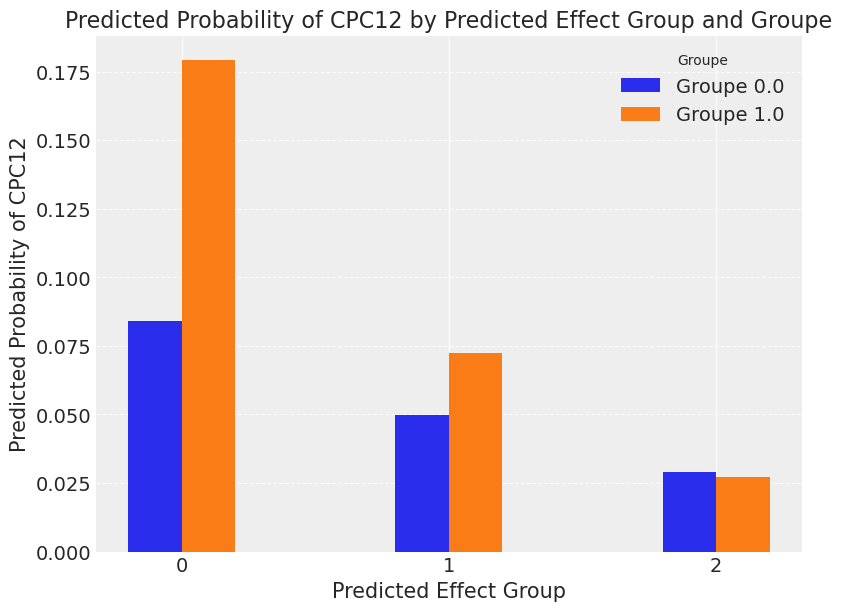

In [109]:
myNewXValue = myXValue.copy()
myNewXValue = myNewXValue.drop(columns=['groupe'])
myPipelineSteps = getDefaultPipelineSteps(myNewXValue)
myPipelineSteps.append(('clf', KMeans(n_clusters=3, n_init=200)))
myPipeline = Pipeline(myPipelineSteps)
myPipeline.fit(myNewXValue)
myGroups = myPipeline.predict(myNewXValue)
myClassifierTest = 'CPC12'
p_value, myModel, myData= getTreatmentEffectDiffUnsupervised(myXValue, myPredictorsDf[myClassifierTest], myGroups, myClassifierTest)
print(f'Silhouette Score of Clusters: {silhouette_score(Pipeline(getDefaultPipelineSteps(myNewXValue)).fit_transform(myNewXValue), myGroups)}')
plotPredictedEffectDiff(aData = myData, aBestModel = myModel)

Optimization terminated successfully.
         Current function value: 0.269269
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.268976
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.3401660605788379
p-value: 0.5597333842916292
Degress of freedom: 1.0
Silhouette score of clusters: 0.037836345964076104


C:\Users\mbranda1\lcicm\analysisFunctions\machine_learning.py:277: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


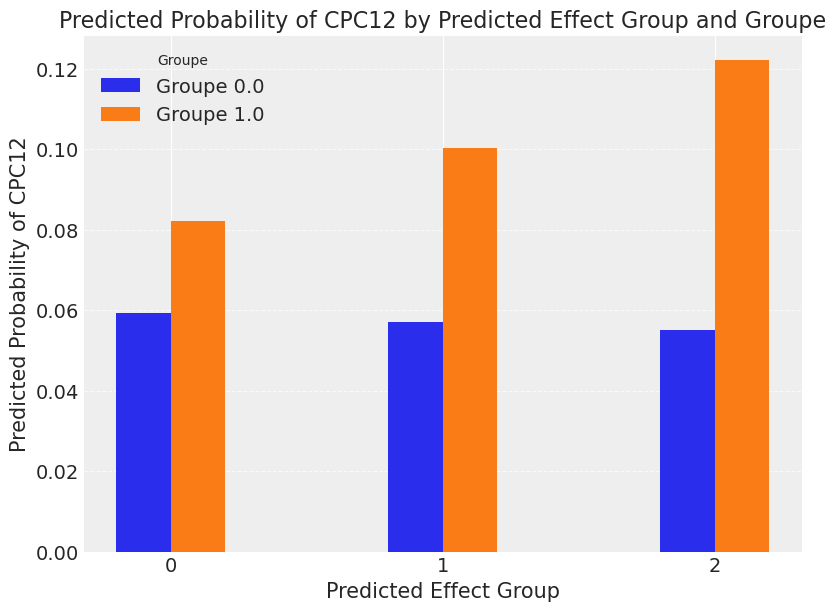

In [107]:
myNewXValue = myXValue.copy()
myNewXValue = myNewXValue.drop(columns=['groupe'])
myPipelineSteps = getDefaultPipelineSteps(myNewXValue)
myPipelineSteps.append(('clf', AgglomerativeClustering(n_clusters=3)))
myPipeline = Pipeline(myPipelineSteps)
myGroups = myPipeline.fit_predict(myNewXValue)
myClassifierTest = 'CPC12'
p_value, myModel, myData= getTreatmentEffectDiffUnsupervised(myXValue, myPredictorsDf[myClassifierTest], myGroups, myClassifierTest)
print(f'Silhouette score of clusters: {silhouette_score(Pipeline(getDefaultPipelineSteps(myNewXValue)).fit_transform(myNewXValue), myGroups)}')
plotPredictedEffectDiff(aData = myData, aBestModel = myModel)

In [224]:
myTree = DecisionTreeClassifier(min_samples_split=5, max_depth=2)
myNewXValue = myXValue.copy()
myNewXValue = myNewXValue.drop(columns=['groupe'])
myTree.fit(myNewXValue[ei_columns], myGroups)
accuracy_score(myTree.predict(myNewXValue[ei_columns]), myGroups)

0.9982788296041308

[Text(0.6, 0.8333333333333334, 'EI_HEMOSEVER <= inf\ngini = 0.437\nsamples = 581\nvalue = [420.0, 97.0, 64.0]'),
 Text(0.4, 0.5, 'EI_CONVULS <= 0.5\ngini = 0.479\nsamples = 161\nvalue = [0.0, 97.0, 64.0]'),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 96\nvalue = [0, 96, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.03\nsamples = 65\nvalue = [0, 1, 64]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 420\nvalue = [420, 0, 0]')]

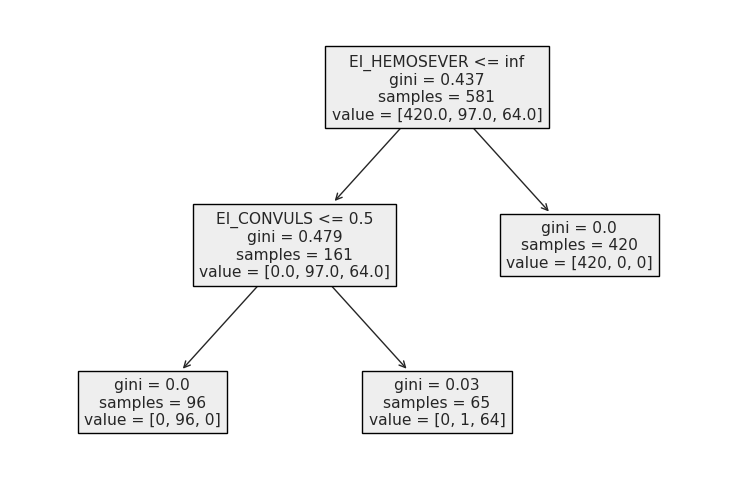

In [244]:
# plt.figure(figsize=(5,10))
# 
tree.plot_tree(myTree, feature_names=ei_columns)

In [213]:
myDfs = readDfs()
bio_data_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[52:76])
# bio_data_columns.append('SUBJID')
bio_data_columns_descr = list(myDfs['Description_tables_variables']['Label'].iloc[52:76])
bio_visit_column = 'VISIT'
cpc_column = 'CPC_SC3'
group_colums = ['V0_BRAS2', 'groupe']
ds_columns = 'DS_DATA_REFUS'
ecg_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[137:154])
ecg_columns_descr = list(myDfs['Description_tables_variables']['LabelTranslated'].iloc[137:154])
j0_drop_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[362:384])
j0_reflex_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[273:285])
j0_reflex_columns_descr = list(myDfs['Description_tables_variables']['LabelTranslated'].iloc[273:285])
sofa_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[586:593])
sofa_columns.append('SUBJID')
ei_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[158:168])
ei_columns_descr = list(myDfs['Description_tables_variables']['LabelTranslated'].iloc[158:168])
ei_columns = ei_columns + (['SUBJID', 'EI_ARYTHMI', 'EI_ANTIEPILEPTIQ'])

C:\Program Files\miniconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Optimization terminated successfully.
         Current function value: 0.450350
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.447355
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 3.4809499657437755
p-value: 0.062079092703833924
Degress of freedom: 1.0
Silhouette score of clusters: 0.8577391659261586


C:\Users\mbranda1\AppData\Local\Temp\ipykernel_13512\3846469373.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


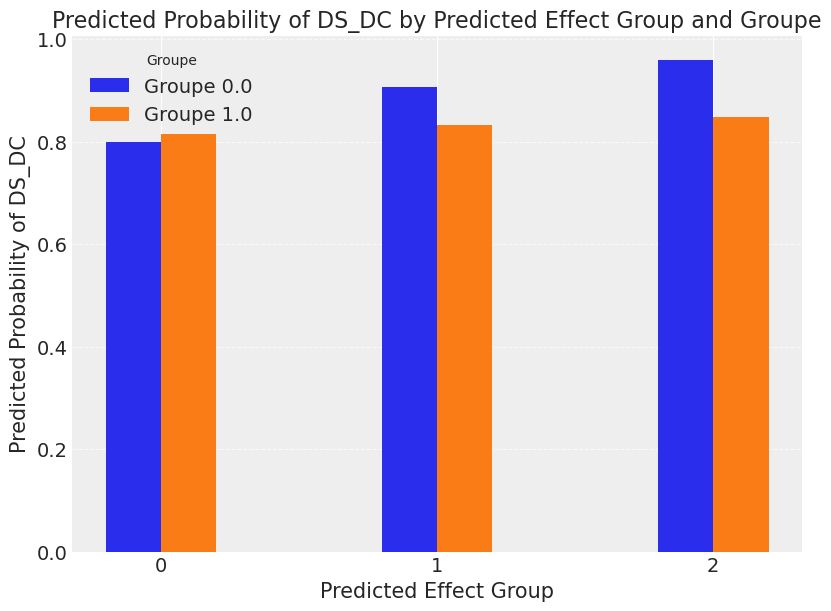

In [255]:
myNewXValue = myXValue.copy()
myNewXValue = myNewXValue.drop(columns=['groupe'])
# ecg_columns.remove('VISIT')
# ecg_columns.remove('SUBJID')
myNewXValue = myNewXValue[ei_columns]
myPipelineSteps = getDefaultPipelineSteps(myNewXValue)
myPipelineSteps.append(('clf', KMeans(n_clusters=3, n_init=300)))
myPipeline = Pipeline(myPipelineSteps)
myPipeline.fit(myNewXValue)
myGroups = myPipeline.predict(myNewXValue)
myClassifierTest = 'DS_DC'
p_value, myModel, myData= getTreatmentEffectDiffUnsupervised(myXValue, myPredictorsDf[myClassifierTest], myGroups, myClassifierTest)
print(f'Silhouette score of clusters: {silhouette_score(Pipeline(getDefaultPipelineSteps(myNewXValue)).fit_transform(myNewXValue), myGroups)}')

plotPredictedEffectDiff(aData = myData, aBestModel = myModel, aCategory = myClassifierTest)

In [233]:
result_physical = ['SEX', 'J0_TAILLE',  'J0_POIDS',  'J0_BMI',  'J0_AGE',  'J0_PAS',  'J0_PAD',  'J0_PAM',  'J0_FC',  'J0_RYTHM']

In [140]:
result = result.split('  ')
result

['J0_CHARLSON1',
 'J0_CHARLSON2',
 'J0_CHARLSON3',
 'J0_CHARLSON4',
 'J0_CHARLSON5',
 'J0_CHARLSON6',
 'J0_CHARLSON7',
 'J0_CHARLSON8',
 'J0_CHARLSON9',
 'J0_CHARLSON10',
 'J0_CHARLSON11',
 'J0_CHARLSON12',
 'J0_CHARLSON13',
 'J0_CHARLSON14',
 'V0_CHARLSON15',
 'V0_CHARLSON16',
 'V0_CHARLSON17',
 'V0_CHARLSON18',
 'V0_CHARLSON18B',
 'V0_CHARLSON19',
 'J0_CHARLSON']

In [152]:
ei_columns

['EI_EI',
 'EI_HEMOSEVER',
 'EI_TRANSFUS',
 'EI_INTRACER',
 'EI_CHIR',
 'EI_EXTRARENAL',
 'EI_OAP',
 'EI_ECHO',
 'EI_DIURETIQ',
 'EI_CONVULS',
 'EI_ARYTHMI',
 'EI_ANTIEPILEPTIQ']

In [153]:
myXValue[ei_columns]

,EI_EI,EI_HEMOSEVER,EI_TRANSFUS,EI_INTRACER,EI_CHIR,EI_EXTRARENAL,EI_OAP,EI_ECHO,EI_DIURETIQ,EI_CONVULS,EI_ARYTHMI,EI_ANTIEPILEPTIQ
0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,10.0,0.0,0.0
3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
576,1.0,1.0,1.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,NaN
577,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
578,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
579,1.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,1.0,0.0,1.0


In [251]:
myNewXValue['predicted_effect_groupe'] = myGroups
myNewXValue['groupe'] = myPredictorsDf['groupe']
myNewXValue['Death by Any Cause'] = myPredictorsDf[myClassifierTest]

In [252]:
myNewXValue.groupby(['predicted_effect_groupe', 'groupe', 'Death by Any Cause']).agg({'Death by Any Cause': 'count'}).rename(columns={'Death by Any Cause': 'Counts'})

Counts
predicted_effect_groupe groupe Death by Any Cause        
0                       0.0    0.0                     40
                               1.0                    167
                        1.0    0.0                     39
                               1.0                    174
1                       0.0    0.0                      8
                               1.0                     41
                        1.0    0.0                      9
                               1.0                     39
2                       0.0    1.0                     41
                        1.0    0.0                      3
                               1.0                     20

In [214]:
ei_columns_descr

['Presence of adverse effects',
 'The patient presented with a severe hemorrhagic complication',
 'Transfusion',
 'Intracerebral hemorrhage',
 'Bleeding requiring surgery',
 'Number of extrarenal purification sessions',
 'Number of cardiogenic OAP episodes',
 'OAP: Ultrasound criterion',
 'OAP: Need for diuretic or nitrate treatment:',
 'Number of clinical seizure episodes']

In [215]:
ei_columns

['EI_EI',
 'EI_HEMOSEVER',
 'EI_TRANSFUS',
 'EI_INTRACER',
 'EI_CHIR',
 'EI_EXTRARENAL',
 'EI_OAP',
 'EI_ECHO',
 'EI_DIURETIQ',
 'EI_CONVULS',
 'SUBJID',
 'EI_ARYTHMI',
 'EI_ANTIEPILEPTIQ']

In [277]:
from econml.dml import CausalForestDML
myNewXValue = myXValue.copy()
myNewXValue = myNewXValue.drop(columns=['groupe'])
X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(myNewXValue, myPredictorsDf['groupe'], myYValue, test_size=0.3)
causal_forest = CausalForestDML(
    model_t=RandomForestRegressor(),    # Model to predict treatment
    model_y=RandomForestRegressor(),    # Model to predict outcome
    n_estimators=100,                   # Number of trees in the forest
    min_samples_leaf=5,
    max_depth=10,
    discrete_treatment=True,            # Indicate binary treatment
)
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
myNewXTrain = myPipeline.fit_transform(X_train)
causal_forest.fit(Y_train, T_train, X=myNewXTrain)

First stage model has discrete target but model is not a classifier!
First stage model has discrete target but model is not a classifier!


In [271]:
myNewXTest = myPipeline.transform(X_test)
CATE_pred = causal_forest.effect(myNewXTest)

print("Predicted CATE for test data:", CATE_pred[:10])

Predicted CATE for test data: [ 0.00796385  0.00536925  0.03054364  0.00046587 -0.03667934  0.01633176
 -0.02867434  0.02757937 -0.02957737  0.02019147]


In [284]:
def plotPredictedTreatmentEffect(myNewDf, aCategory = 'CPC12'):
    lower_third, upper_third, myNewDf = getPredictedThirds(myNewDf)
    if lower_third == upper_third:
        plt.scatter(x = range(len(y_pred_proba1)), y = myNewDf['predicted_effect'].sort_values())
    else:
        myNewDf.sort_values(['predicted_effect'], inplace=True)
        myNewDf.reset_index(inplace=True)
        for group in myNewDf['predicted_effect_group']:
            myFilter = myNewDf['predicted_effect_group'] == group
            plt.scatter(x = myNewDf[myFilter]['predicted_effect'].index, y = myNewDf[myFilter]['predicted_effect'])
        plt.legend(myNewDf['predicted_effect_group'].unique())
    plt.title(f'Predicted treatment effect diff between hypothermia and normothermia for {aCategory}')
    return lower_third, upper_third, myNewDf

In [285]:
myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred

(-0.006280739965467463,
 0.011742102108837834,
      index  predicted_effect predicted_effect_group
 0       65         -0.050382                  Lower
 1       78         -0.044039                  Lower
 2      137         -0.042322                  Lower
 3       95         -0.042002                  Lower
 4      139         -0.040213                  Lower
 ..     ...               ...                    ...
 170     72          0.042290                  Upper
 171    128          0.046853                  Upper
 172     82          0.049868                  Upper
 173     43          0.051020                  Upper
 174     70          0.056748                  Upper
 
 [175 rows x 3 columns])

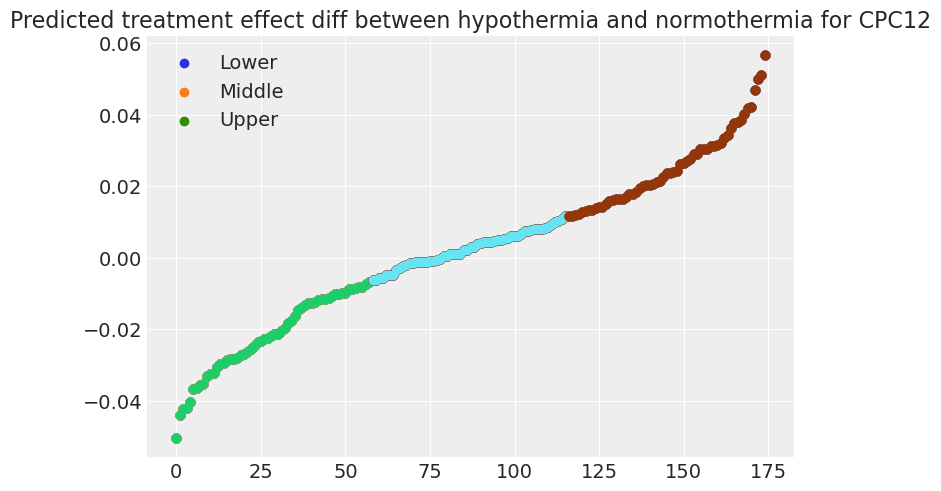

In [286]:
plotPredictedTreatmentEffect(myNewDf)

In [ ]:
def getTreatmentEffectDiff(X_train, y_train, myNewDf, aCategory = 'CPC12'):
    if upper_third == lower_third:
        print(f'No effect difference')
        return 1
    myData = pd.concat([X_train['groupe'], myNewDf['predicted_effect_group'], y_train], axis=1)
    model1 = smf.logit(
        f'{aCategory} ~ predicted_effect_group + groupe',
        data=myData
    ).fit()

    model2 = smf.logit(
        f'{aCategory} ~ predicted_effect_group * groupe',
        data=myData
    ).fit()

    llr = -2*(model1.llf - model2.llf)
    df_diff = model2.df_model - model1.df_model
    p_value = chi2.sf(llr, df_diff)

    print(f'Likelihood ratio of test results:')
    print(f'Chi square statistic: {llr}')
    print(f'p-value: {p_value}')
    print(f'Degress of freedom: {df_diff}')
    return p_value